In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [86]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [87]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [88]:
df.dropna(inplace=True)

In [89]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [90]:
df.shape

(714, 3)

In [91]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [92]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [93]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [94]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [95]:
clf=DecisionTreeClassifier()

In [96]:
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)



In [97]:
accuracy_score(y_test,y_pred)

0.6433566433566433

In [98]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6303208137715179)

In [99]:
kbin_age=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare= KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [100]:
trf=ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [101]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.transform(X_test)

C:\New folder\New folder\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\New folder\New folder\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [102]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [103]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.25  ,   7.775 ,   7.8958,   8.1583,  10.5   ,
               13.    ,  14.4542,  18.75  ,  26.    ,  26.55  ,  31.275 ,
               51.4792,  76.2917, 108.9   , 512.3292])                   ],
      dtype=object)

In [104]:
trf.named_transformers_['first'].n_bins_

array([15])

In [105]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15)}

In [106]:
output=pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
    
})

In [107]:
output['age_labels']=pd.cut(x=X_train['Age'],
                               bins=trf.named_transformers_['first'].bin_edges_[0].tolist() )
output['fare_labels']=pd.cut(x=X_train['Fare'],
                                bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [108]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
710,24.0,5.0,49.5042,11.0,"(23.0, 25.0]","(31.275, 51.479]"
645,48.0,13.0,76.7292,13.0,"(47.0, 54.0]","(76.292, 108.9]"
150,51.0,13.0,12.5250,5.0,"(47.0, 54.0]","(10.5, 13.0]"
801,31.0,8.0,26.2500,9.0,"(30.0, 32.0]","(26.0, 26.55]"
808,39.0,11.0,13.0000,6.0,"(38.0, 42.0]","(10.5, 13.0]"


In [109]:
clf=DecisionTreeClassifier()

In [110]:
clf.fit(X_train_trf,y_train)
y_pred2=clf.predict(X_test_trf)
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [111]:
trf=trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

C:\New folder\New folder\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\New folder\New folder\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6331377151799686)

In [112]:
def discritizer(bins,strategy):
    kbin_age=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy=strategy)
    kbin_fare= KBinsDiscretizer(n_bins=15,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf=trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title('Before ')


    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title('After')

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title('Before ')


    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title('After')


    plt.show()
    

In [113]:
import os

os.environ["OMP_NUM_THREADS"] = "3"

C:\New folder\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\New folder\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


0.6317097026604068


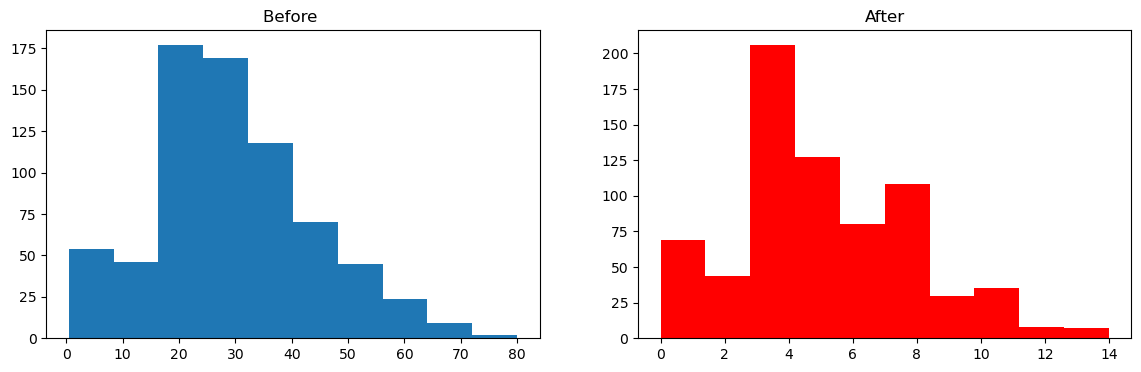

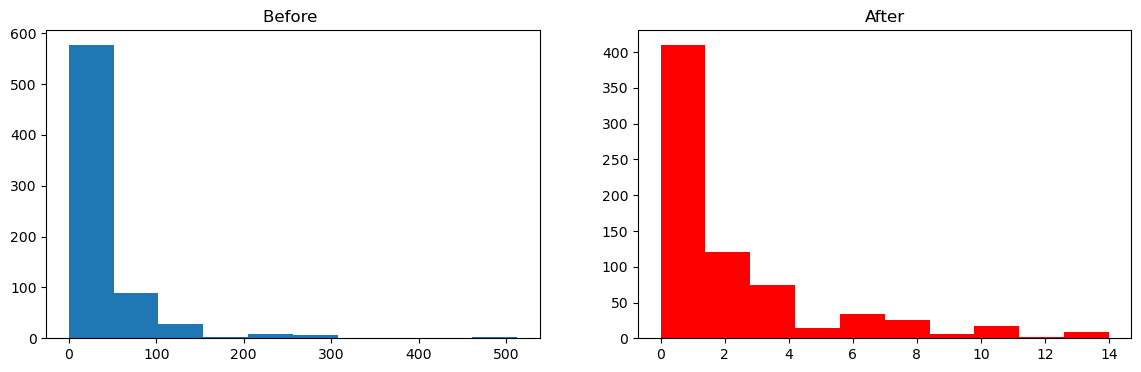

In [115]:
discritizer(5,'kmeans')